In [1]:
!pip install tensorflow
!pip install matplotlib
!pip install ipywidgets

In [2]:
# Import necessary libraries
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter
import io
import ipywidgets as widgets


# Introduction
This lab is designed to introduce you to the basics of deep learning by interacting with a pre-built model. You'll understand the workflow of a deep learning project, including data preprocessing, model architecture, and making predictions. The goal is to familiarize yourself with the basics of deep learning without writing any code.


In [3]:
# Load the VGG16 model
model = VGG16(weights='imagenet')

# Display the model architecture
model.summary()


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

             THE 5-STAR RESTAURANT KITCHEN - VGG16 ANALOGY

VGG16 operates like a high-end restaurant kitchen identifying what dish a customer
ordered just by looking at a photo of the plate.

  • Total Parameters : 138,357,544 (~527.79 MB)
  • Target Classes   : 1,000 Menu Dishes (ImageNet)

  • Station 1: Prep Cooks (Early layers)     -> Spot colors, raw textures & grill marks (64 channels)
  • Station 2: Line Cooks (Middle layers)    -> Assemble basic parts like crusts & sauces (128 channels)
  • Station 3: Sous Chefs (Deep layers)      -> Spot complete menu components (256 -> 512 channels)
  • Station 4: Head Chef Prep (Deep layers)  -> Refine rich, complex dishes (512 channels)
  • Final Head Chef & Waitstaff (fc1 & out)  -> Weigh 25,088 clues across a 1,000-item menu



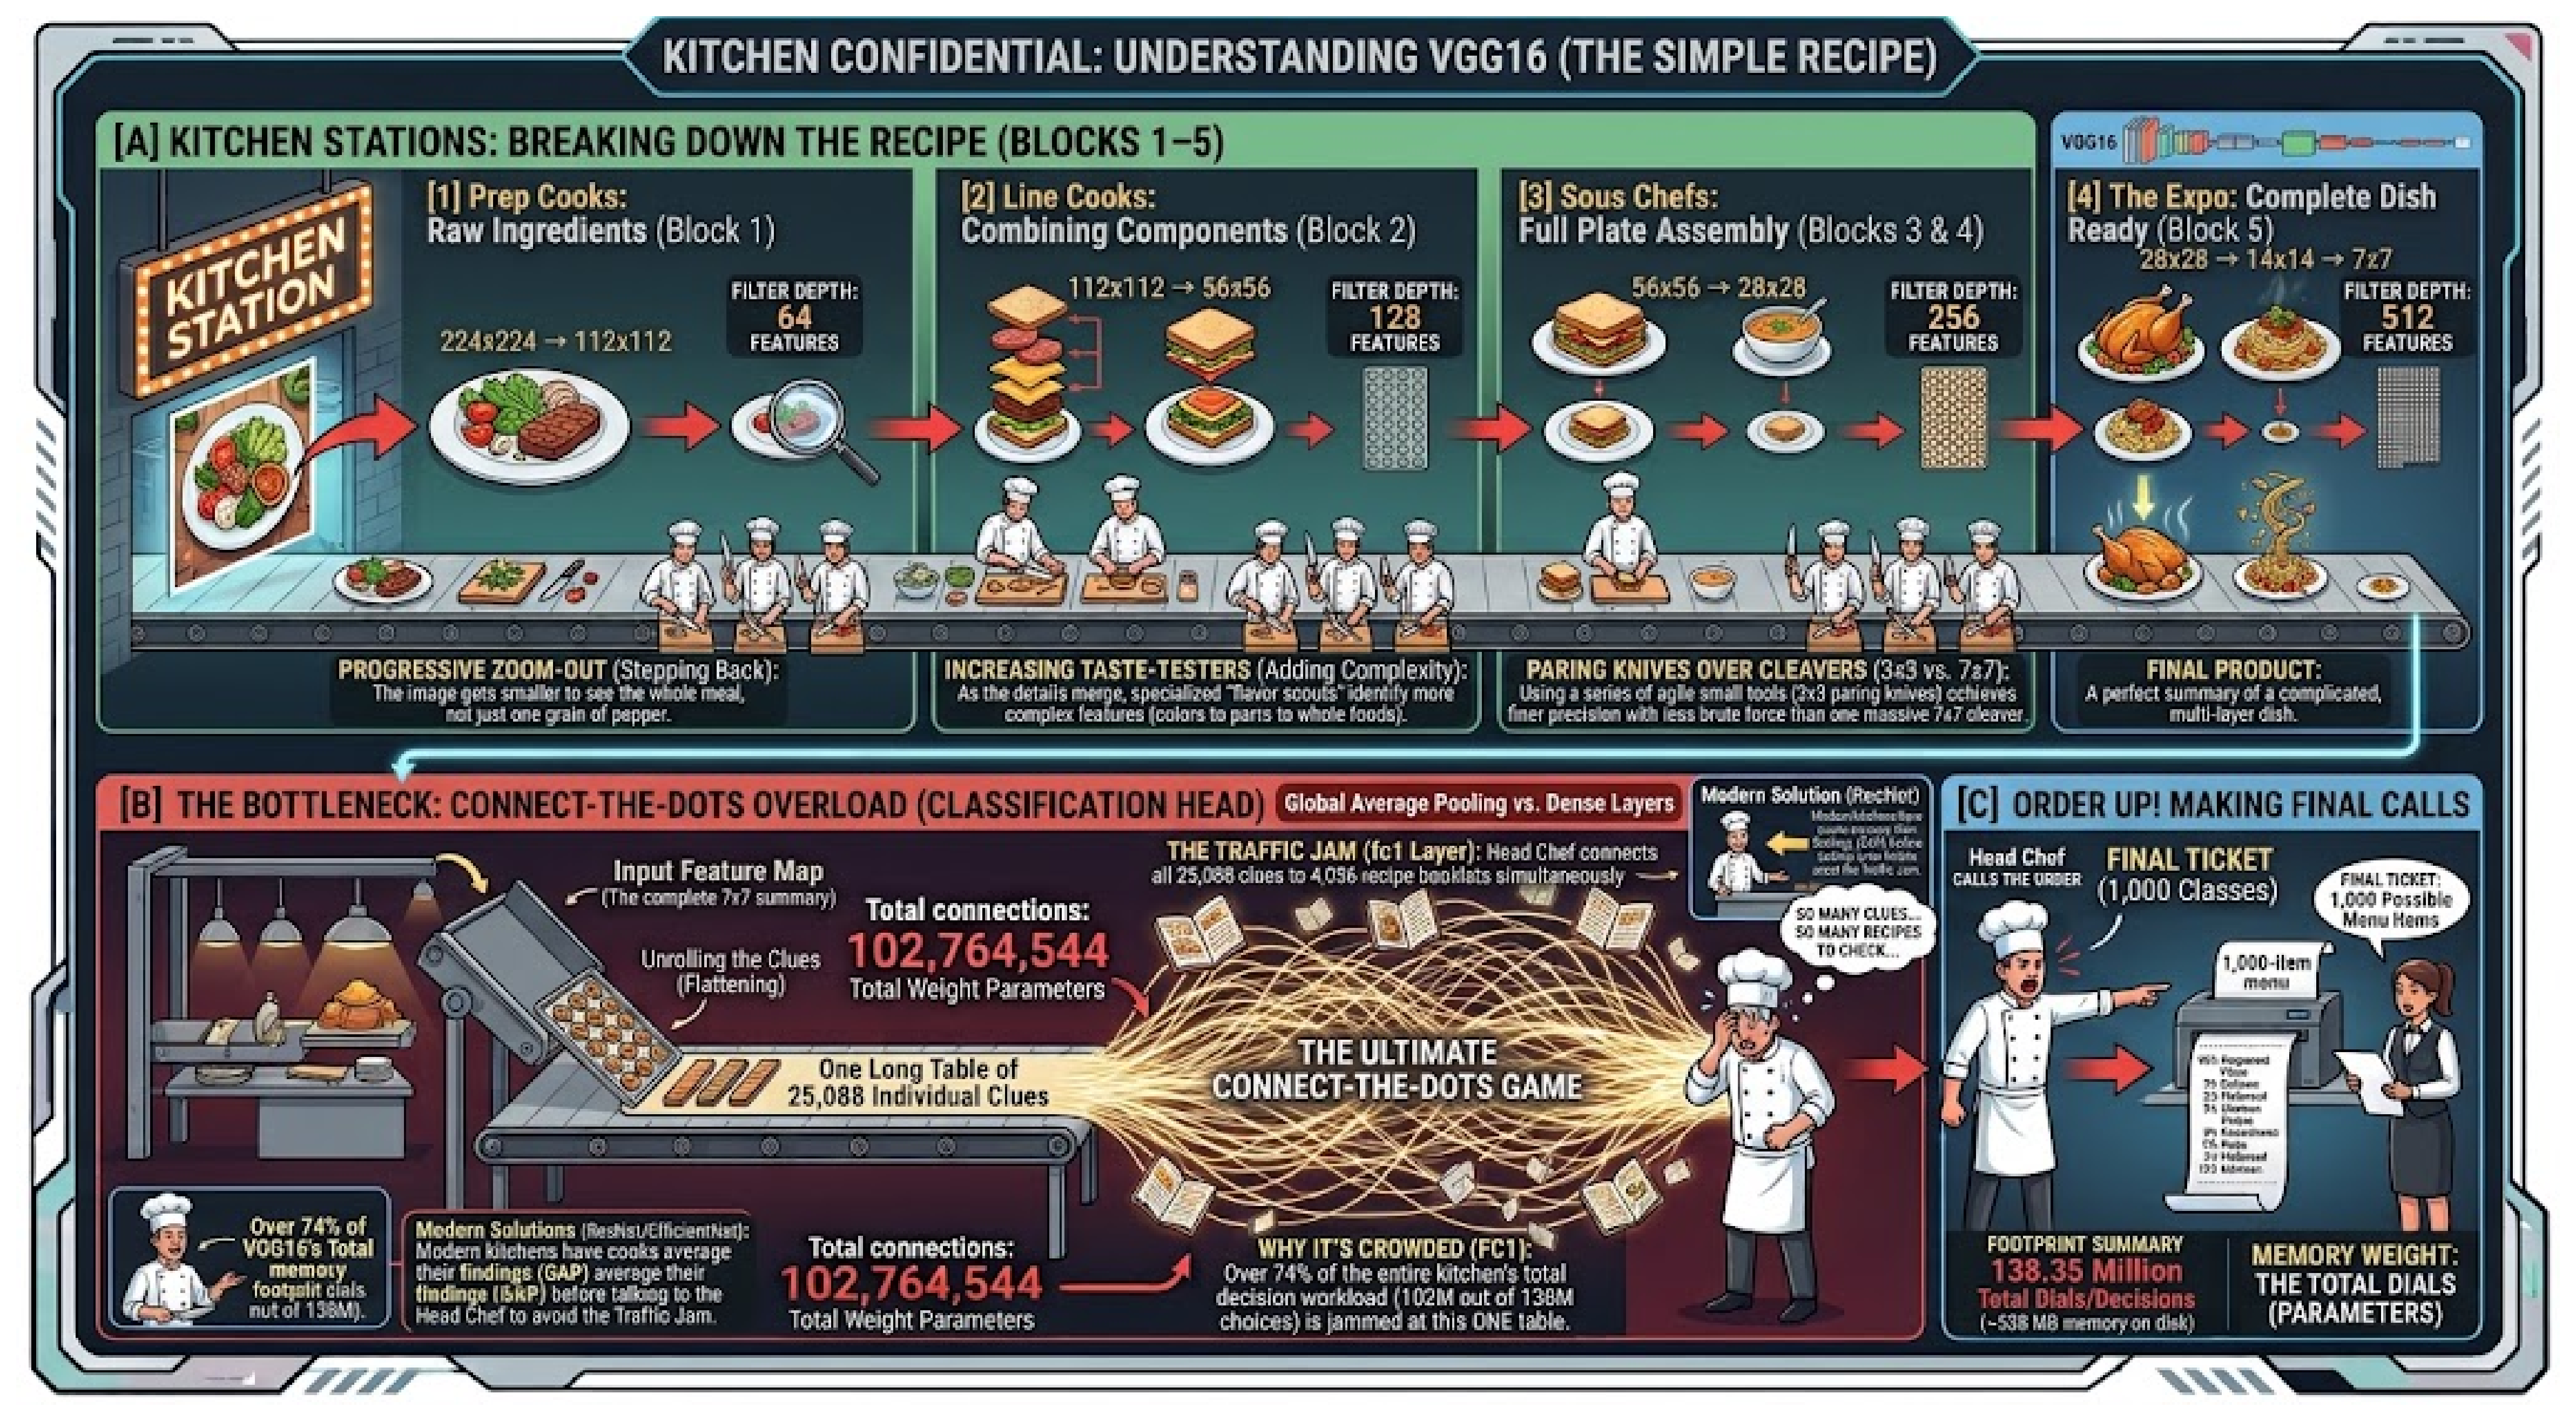

 [A] THE KITCHEN STATIONS (Condensing the Meal)
--------------------------------------------------------------------------------
  • Progressive Spatial Downsampling (Stepping Back):
    Plate size shrinks: 224x224 -> 112x112 -> 56x56 -> 28x28 -> 14x14 -> 7x7.
    Cooks zoom out at each step to see the whole meal rather than individual pepper grains.

  • Channel Depth Expansion (Taste-Testers):
    Filter depth ramps up: 64 -> 128 -> 256 -> 512 -> 512.
    The kitchen trades raw pixel details for rich semantic flavor notes.

  • Stacked 3x3 Lenses (Small Paring Knives):
    Using agile 3x3 paring knives instead of one clumsy 7x7 meat cleaver.

 [B] THE BOTTLENECK (The Chaotic Expo Counter)
--------------------------------------------------------------------------------
  • Flattening the Flavor Board:
    The final 7x7x512 prep tray is dumped onto One Long Table of 25,088 clues.

  • The Traffic Jam Layer (fc1):
    The Head Chef tries connecting 25,088 clues to 4,096 recipe checklist

In [4]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG16

# ==============================================================================
# LOAD MODEL & EXTRACT KEY METRICS
# ==============================================================================
model = VGG16(weights="imagenet")
total_params = model.count_params()
total_mb = (total_params * 4) / (1024**2)

# ==============================================================================
#  5-STAR RESTAURANT KITCHEN OVERVIEW
# ==============================================================================
print("=" * 80)
print("             THE 5-STAR RESTAURANT KITCHEN - VGG16 ANALOGY")
print("=" * 80)
print(
    f"""
VGG16 operates like a high-end restaurant kitchen identifying what dish a customer
ordered just by looking at a photo of the plate.

  • Total Parameters : {total_params:,} (~{total_mb:.2f} MB)
  • Target Classes   : 1,000 Menu Dishes (ImageNet)

  • Station 1: Prep Cooks (Early layers)     -> Spot colors, raw textures & grill marks (64 channels)
  • Station 2: Line Cooks (Middle layers)    -> Assemble basic parts like crusts & sauces (128 channels)
  • Station 3: Sous Chefs (Deep layers)      -> Spot complete menu components (256 -> 512 channels)
  • Station 4: Head Chef Prep (Deep layers)  -> Refine rich, complex dishes (512 channels)
  • Final Head Chef & Waitstaff (fc1 & out)  -> Weigh 25,088 clues across a 1,000-item menu
"""
)

# ==============================================================================
#  SHOW THE ARCHITECTURAL DIAGRAM
# ==============================================================================
img = mpimg.imread("/content/TheAnalogy.jpeg")
plt.figure(figsize=(16, 9), dpi=300)
plt.imshow(img, interpolation="nearest")
plt.axis("off")
plt.tight_layout()
plt.show()

# ==============================================================================
#  WALKTHROUGH & TAKEAWAYS
# ==============================================================================
print("=" * 80)
print(" [A] THE KITCHEN STATIONS (Condensing the Meal)")
print("-" * 80)
print(
    """  • Progressive Spatial Downsampling (Stepping Back):
    Plate size shrinks: 224x224 -> 112x112 -> 56x56 -> 28x28 -> 14x14 -> 7x7.
    Cooks zoom out at each step to see the whole meal rather than individual pepper grains.

  • Channel Depth Expansion (Taste-Testers):
    Filter depth ramps up: 64 -> 128 -> 256 -> 512 -> 512.
    The kitchen trades raw pixel details for rich semantic flavor notes.

  • Stacked 3x3 Lenses (Small Paring Knives):
    Using agile 3x3 paring knives instead of one clumsy 7x7 meat cleaver."""
)

print("\n" + "=" * 80)
print(" [B] THE BOTTLENECK (The Chaotic Expo Counter)")
print("-" * 80)
print(
    """  • Flattening the Flavor Board:
    The final 7x7x512 prep tray is dumped onto One Long Table of 25,088 clues.

  • The Traffic Jam Layer (fc1):
    The Head Chef tries connecting 25,088 clues to 4,096 recipe checklists:
    Total connections: (25,088 * 4,096) + 4,096 = 102,764,544 decisions!
    Traffic Jam: Over 74% of the entire kitchen workload is jammed into this single step.

  • Modern Solution (ResNet):
    Replaces this bottleneck with Global Average Pooling (one neat average per tray)."""
)

print("\n" + "=" * 80)
print(" [C] CALLING OUT THE ORDER (Final Predictions)")
print("-" * 80)
print(
    """  • The Order Ticket:
    Expediter prints confidence across a 1,000-item menu (e.g., 95% Pepperoni Pizza).

  • Waitstaff:
    Weighs final components and announces the exact dish."""
)

print("\n" + "=" * 80)
print("SUMMARY")
print("=" * 80)
print(
    """VGG16 acts like a kitchen assembly line—condensing a detailed photo to a broad summary
while ramping up flavor detectors. Its only flaw is a massive 102-million-decision
traffic jam at the final expo counter where all prep clues hit the Head Chef at once.
"""
)
print("=" * 80)

Loading Master Chef (VGG16 ImageNet weights)...
VGG16 Loaded Successfully!

Upload your food photo:


Saving Sample.png to Sample (1).png

Successfully loaded and preprocessed: Sample (1).png


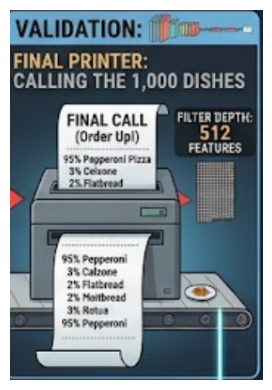

+--------------------------------------+
| VALIDATION: FINAL PRINTER             |
| CALLING THE 1,000 DISHES             |
+--------------------------------------+
|               FINAL CALL             |
|              (Order Up!)             |
| ------------------------------------ |
|   38% Cash Machine                   |
|   14% Power Drill                    |
|    5% Printer                        |
|    4% Hand-Held Computer             |
|    3% Web Site                       |
| ------------------------------------ |
|  FILTER DEPTH: 512 FEATURES          |
+--------------------------------------+


In [9]:
import io
from google.colab import files
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array

# Pre-trained Master Chef (VGG16)
print("Loading Master Chef (VGG16 ImageNet weights)...")
model = VGG16(weights="imagenet")
print("VGG16 Loaded Successfully!\n")


# Preprocess
def load_and_preprocess_image(image_bytes, target_size=(224, 224)):
  raw_img = Image.open(io.BytesIO(image_bytes)).convert("RGB")
  resized_img = raw_img.resize(target_size)
  img_array = img_to_array(resized_img)
  img_batch = np.expand_dims(img_array, axis=0)
  processed_batch = preprocess_input(img_batch)
  return raw_img, processed_batch


# Upload
print("Upload your food photo:")
uploaded = files.upload()

for filename, content in uploaded.items():
  sample_image, processed_image = load_and_preprocess_image(content)
  print(f"\nSuccessfully loaded and preprocessed: {filename}")

# Display the image
  plt.figure(figsize=(4, 4))
  plt.imshow(sample_image)
  plt.axis("off")
  plt.tight_layout()
  plt.show()
# Process
  break
  from tensorflow.keras.applications.vgg16 import decode_predictions

# Make predictions across the 1,000 ImageNet menu items
predictions = model.predict(processed_image, verbose=0)

# Decode top predictions (up to 5 to model the ticket strip)
decoded_predictions = decode_predictions(predictions, top=5)[0]

# Print receipt modeled directly on the visual diagram
print("+" + "-" * 38 + "+")
print("| VALIDATION: FINAL PRINTER             |")
print("| CALLING THE 1,000 DISHES             |")
print("+" + "-" * 38 + "+")
print("|               FINAL CALL             |")
print("|              (Order Up!)             |")
print("| " + "-" * 36 + " |")

for rank, (class_id, label, prob) in enumerate(decoded_predictions, start=1):
  clean_label = label.replace("_", " ").title()
  percentage = f"{int(round(prob * 100))}%"
  line = f"{percentage:>4} {clean_label}"
  print(f"|  {line:<34}  |")

print("| " + "-" * 36 + " |")
print("|  FILTER DEPTH: 512 FEATURES          |")
print("+" + "-" * 38 + "+")

In [7]:
import io
import ipywidgets as widgets
from IPython.display import clear_output, display
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from tensorflow.keras.applications.vgg16 import (
    decode_predictions,
    preprocess_input,
)
from tensorflow.keras.preprocessing.image import img_to_array

# 1. Setup UI Widgets
upload = widgets.FileUpload(
    accept="image/*", multiple=False, description="Upload Dish"
)
predict_button = widgets.Button(
    description="Call Order Up!",
    button_style="success",
    icon="utensils",
    tooltip="Run VGG16 Inference",
)
output_area = widgets.Output()

display(widgets.HBox([upload, predict_button]), output_area)


# 2. Click Handler
def on_predict_clicked(b):
  with output_area:
    clear_output()

    if not upload.value:
      print("⚠️ Please upload an image first using the 'Upload Dish' button.")
      return

    try:
      if isinstance(upload.value, dict):
        first_file = next(iter(upload.value.values()))
        img_bytes = first_file["content"]
      else:
        first_file = upload.value[0]
        img_bytes = (
            first_file["content"]
            if isinstance(first_file, dict)
            else first_file.content
        )
    except Exception as e:
      print(f"Error reading file: {e}")
      return

    # Process Image
    raw_img = Image.open(io.BytesIO(img_bytes)).convert("RGB")
    resized_img = raw_img.resize((224, 224))

    img_array = img_to_array(resized_img)
    img_batch = np.expand_dims(img_array, axis=0)
    processed_tensor = preprocess_input(img_batch)

    # Predict
    raw_preds = model.predict(processed_tensor, verbose=0)
    top_preds = decode_predictions(raw_preds, top=5)[0]

    # Show Image
    plt.figure(figsize=(4, 4))
    plt.imshow(raw_img)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    # Formatted Receipt
    print("+" + "-" * 38 + "+")
    print("| VALIDATION: FINAL PRINTER             |")
    print("| CALLING THE 1,000 DISHES             |")
    print("+" + "-" * 38 + "+")
    print("|               FINAL CALL             |")
    print("|              (Order Up!)             |")
    print("| " + "-" * 36 + " |")

    for rank, (class_id, label, prob) in enumerate(top_preds, start=1):
      clean_label = label.replace("_", " ").title()
      percentage = f"{int(round(prob * 100))}%"
      line = f"{percentage:>4} {clean_label}"
      print(f"|  {line:<34}  |")

    print("| " + "-" * 36 + " |")
    print("|  FILTER DEPTH: 512 FEATURES          |")
    print("+" + "-" * 38 + "+")


predict_button.on_click(on_predict_clicked)


Output()

# Conclusion and Discussion
Reflect on the lab activities. Discuss how the pre-trained model was able to make predictions, the role of data preprocessing, and the impact of input modifications on the model's predictions.
